In [1]:
pip install pandas matplotlib seaborn mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Boromir@2026",
    database="upi_project"
)

query = "SELECT * FROM transactions"
df = pd.read_sql(query, conn)

print(df.head())

   transaction_id  user_id    amount transaction_type device_type   location  \
0          100000     4174  12377.50              P2P         Web  Hyderabad   
1          100001     4507  43316.00         Recharge         Web      Delhi   
2          100002     1860   8239.78         Recharge         iOS    Chennai   
3          100003     2294  20762.10         Recharge         Web     Mumbai   
4          100004     2130    726.40         Merchant         Web      Delhi   

  time_of_transaction  failed_attempts  is_night  new_device  \
0 2026-03-11 07:49:08                3         0           1   
1 2026-04-14 14:44:08                2         1           0   
2 2026-04-16 15:58:08                4         1           1   
3 2026-04-09 21:02:08                2         0           1   
4 2026-04-19 06:19:08                1         1           0   

   transaction_velocity  fraud_flag risk_level  
0                  3.72           0       High  
1                  2.40           0 

C:\Users\satya\AppData\Local\Temp\ipykernel_22248\2102230939.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


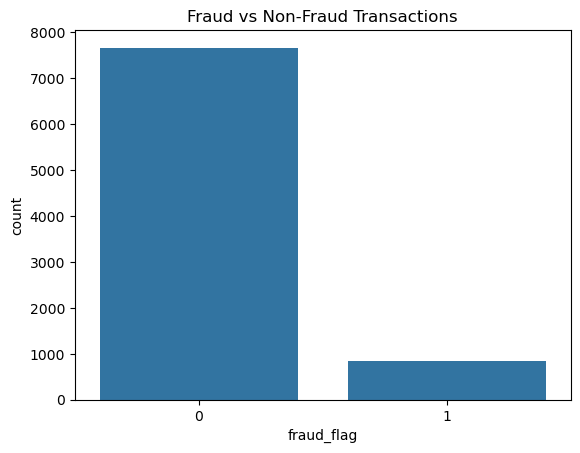

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fraud_flag', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

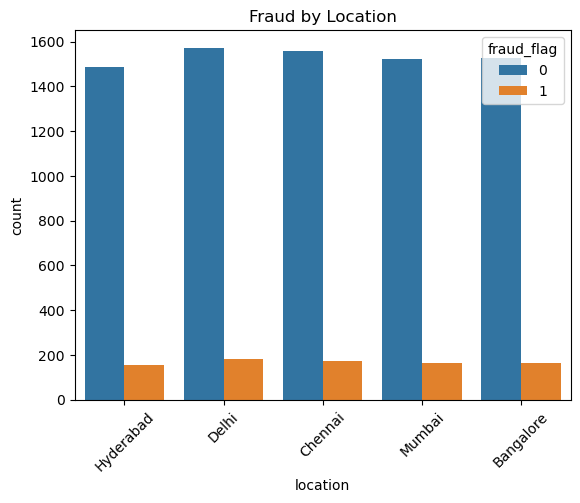

In [4]:
sns.countplot(x='location', hue='fraud_flag', data=df)
plt.xticks(rotation=45)
plt.title("Fraud by Location")
plt.show()

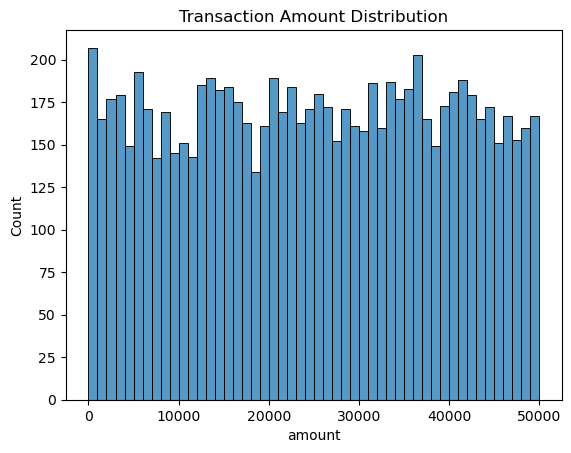

In [5]:
sns.histplot(df['amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

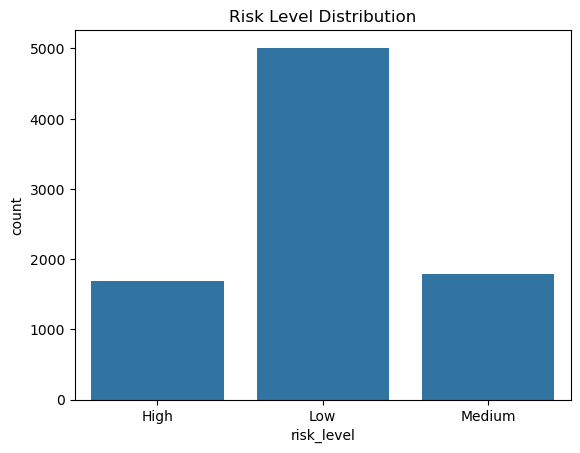

In [6]:
sns.countplot(x='risk_level', data=df)
plt.title("Risk Level Distribution")
plt.show()

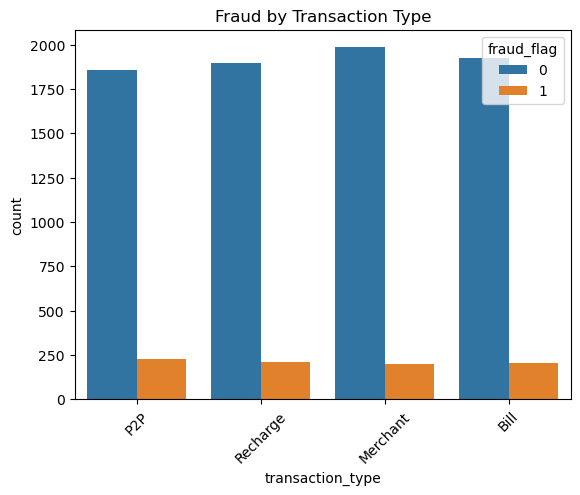

In [7]:
sns.countplot(x='transaction_type', hue='fraud_flag', data=df)
plt.xticks(rotation=45)
plt.title("Fraud by Transaction Type")
plt.show()

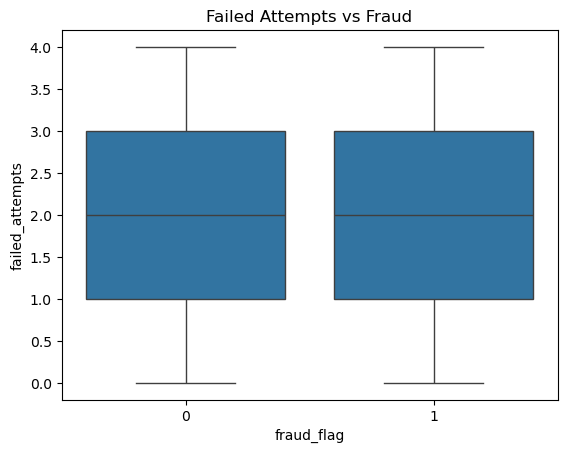

In [8]:
sns.boxplot(x='fraud_flag', y='failed_attempts', data=df)
plt.title("Failed Attempts vs Fraud")
plt.show()